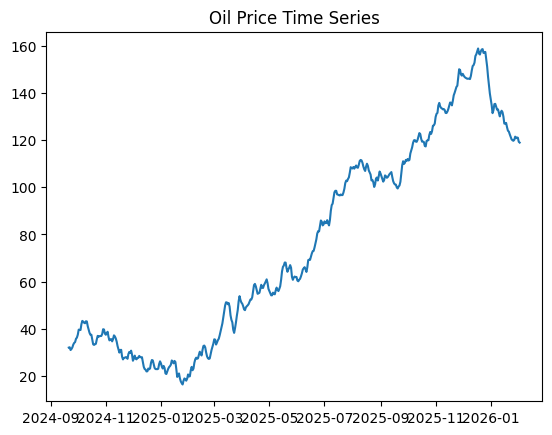

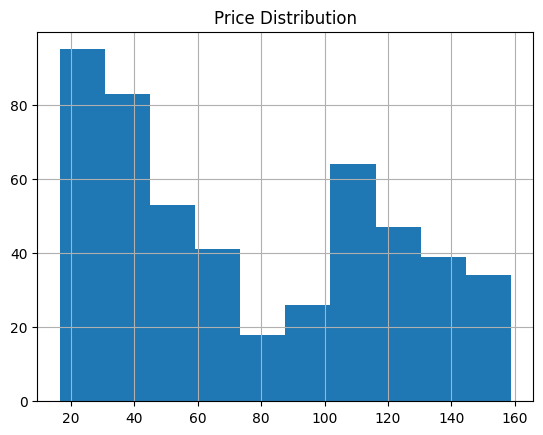

ADF Statistic: -0.5462340182601634
p-value: 0.8826741397403068


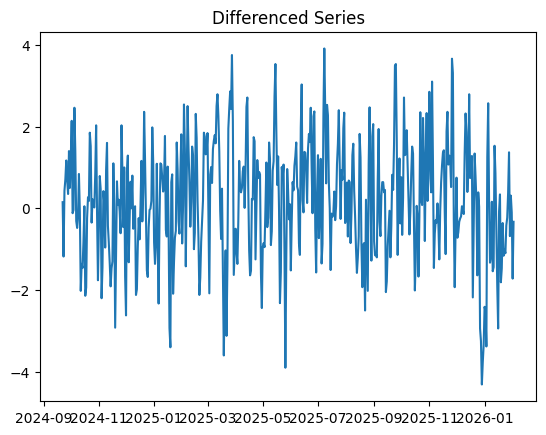

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Best ARIMA Order: (3, 1, 4)
Best AIC: 1125.3801551359672


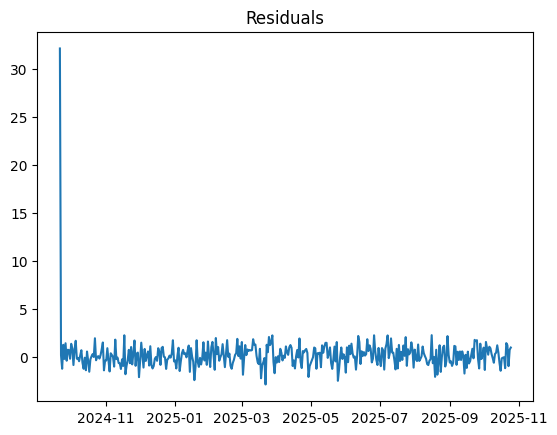

<Figure size 640x480 with 0 Axes>

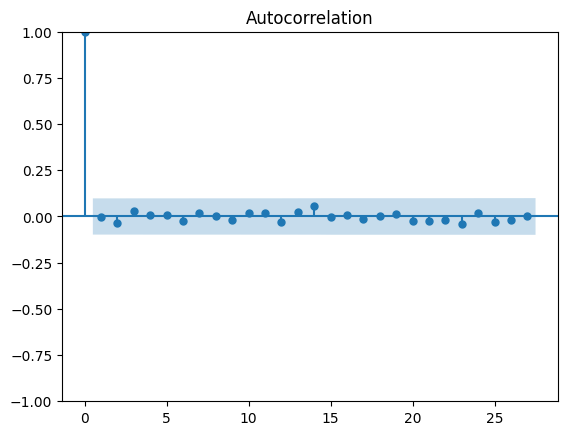

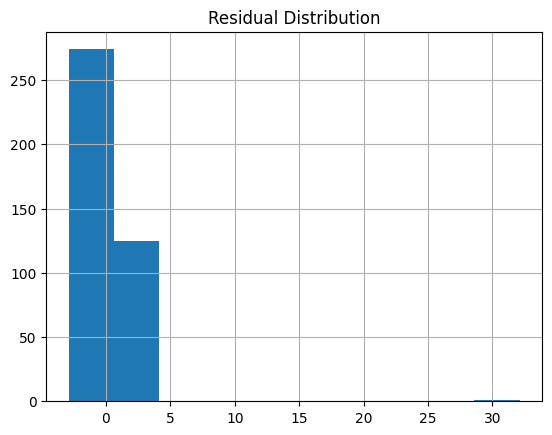

RMSE: 18.6408875169387


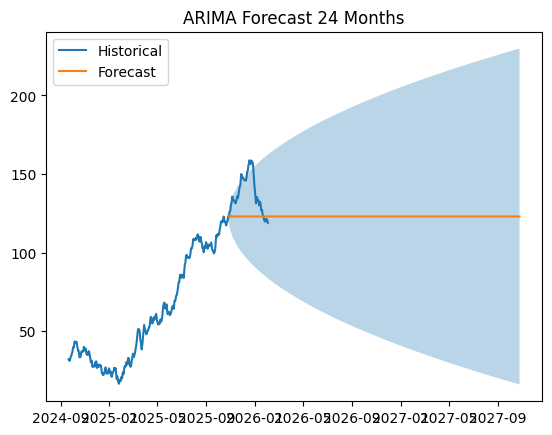

In [1]:

# PART 1 : ARIMA MODEL


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import warnings

warnings.filterwarnings("ignore")

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_squared_error


# Load dataset


df = pd.read_csv("oil_prices_2426.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df = df.asfreq('D')
df.rename(columns={'price (dollars)': 'price'}, inplace=True)

price = df['price']


# Exploratory Data Analysis


plt.figure()
plt.plot(price)
plt.title("Oil Price Time Series")
plt.show()

plt.figure()
price.hist()
plt.title("Price Distribution")
plt.show()


# Stationarity Test (ADF)


result = adfuller(price)

print("ADF Statistic:", result[0])
print("p-value:", result[1])


# Differencing if needed


diff_series = price.diff().dropna()

plt.figure()
plt.plot(diff_series)
plt.title("Differenced Series")
plt.show()


# Train Test Split


split = int(len(price)*0.8)

train = price[:split]
test = price[split:]


# Grid Search ARIMA


p = range(0,9)
d = range(0,3)
q = range(0,9)

best_aic = np.inf
best_order = None
best_model = None

for order in itertools.product(p,d,q):

    try:

        model = ARIMA(train, order=order)
        model_fit = model.fit()

        if model_fit.aic < best_aic:
            best_aic = model_fit.aic
            best_order = order
            best_model = model_fit

    except:
        continue

print("Best ARIMA Order:", best_order)
print("Best AIC:", best_aic)


# Residual Analysis


residuals = best_model.resid

plt.figure()
plt.plot(residuals)
plt.title("Residuals")
plt.show()

plt.figure()
plot_acf(residuals)
plt.show()

plt.figure()
residuals.hist()
plt.title("Residual Distribution")
plt.show()


# Test Prediction Performance


forecast_test = best_model.forecast(steps=len(test))

rmse = np.sqrt(mean_squared_error(test, forecast_test))

print("RMSE:", rmse)


# Forecast 24 Months


forecast_steps = 730

forecast = best_model.get_forecast(steps=forecast_steps)

forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

plt.figure()

plt.plot(price, label="Historical")
plt.plot(forecast_mean, label="Forecast")

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.3
)

plt.legend()
plt.title("ARIMA Forecast 24 Months")
plt.show()

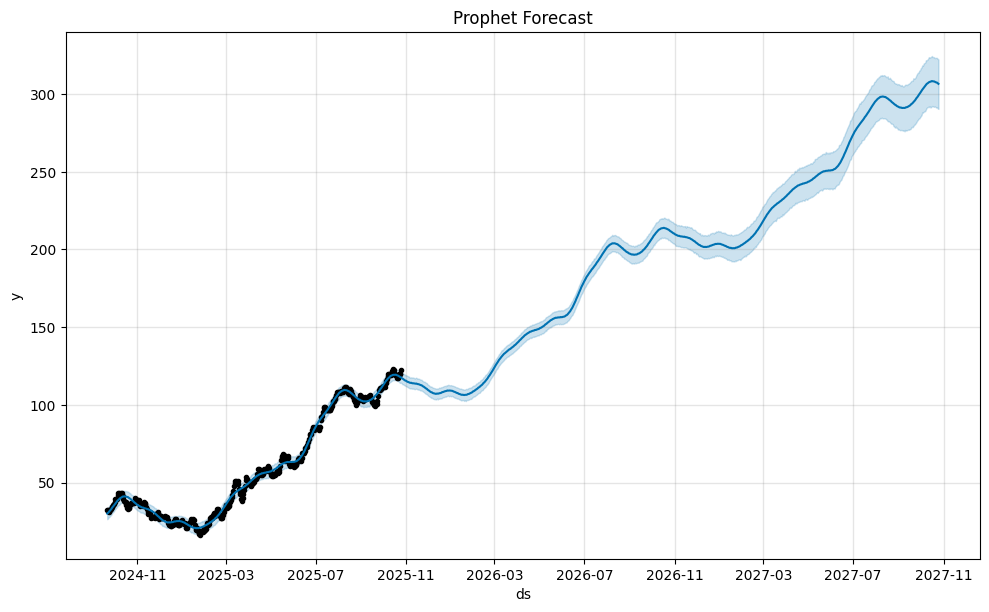

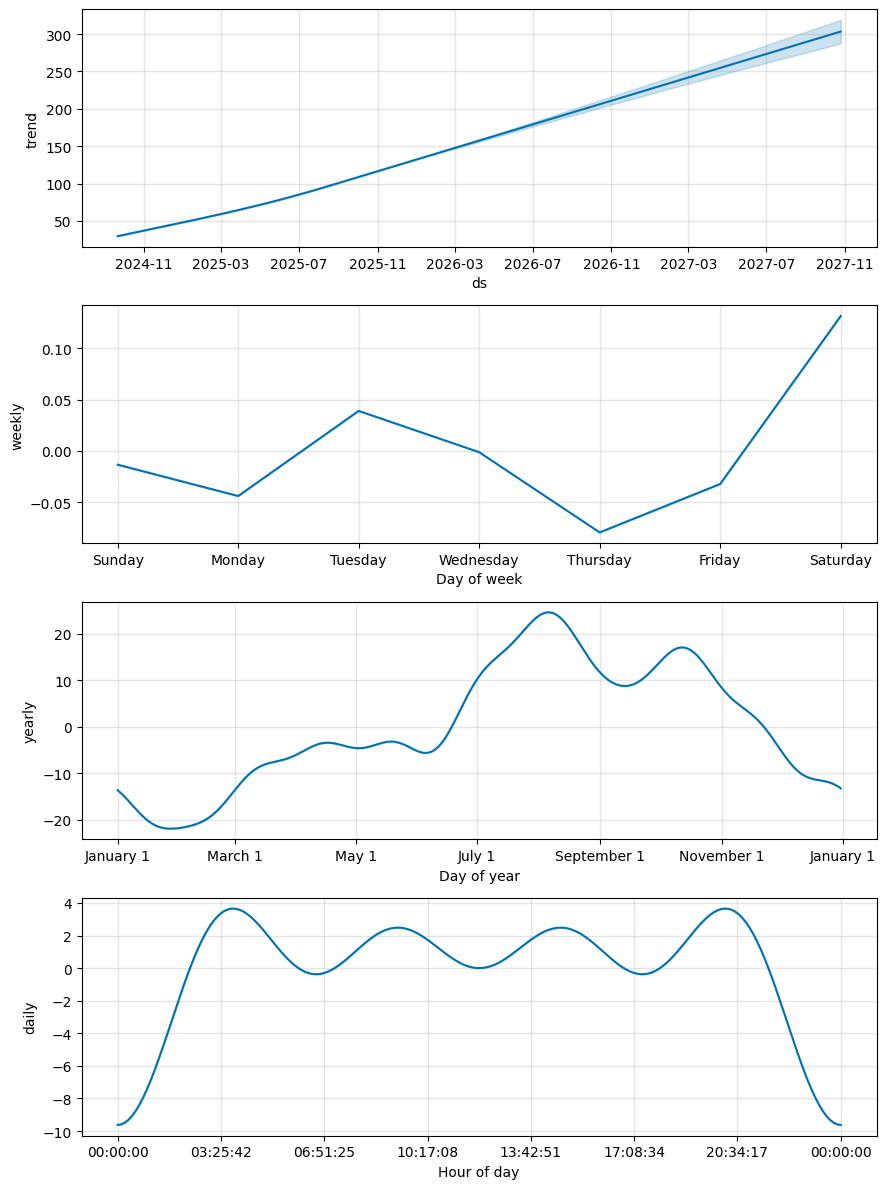

Prophet RMSE: 30.2751411667944
Prophet MAE: 27.52328631081291


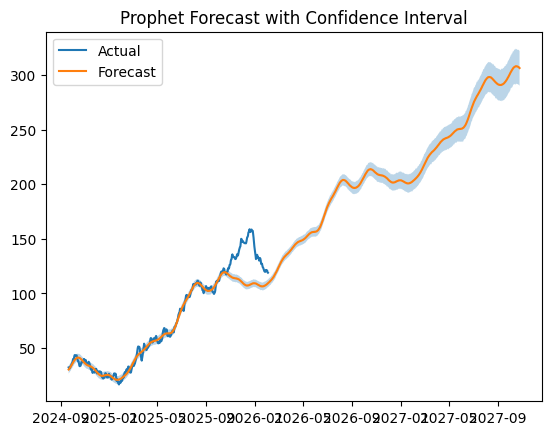

In [2]:

#  PROPHET MODEL


from prophet import Prophet
from sklearn.metrics import mean_absolute_error


# Prepare Data for Prophet


prophet_df = df.reset_index()

prophet_df = prophet_df.rename(columns={
    'date':'ds',
    'price':'y'
})


# Train Test Split


split = int(len(prophet_df)*0.8)

train = prophet_df[:split]
test = prophet_df[split:]


# Build Prophet Model


model = Prophet(
    daily_seasonality=True,
    yearly_seasonality=True
)

model.fit(train)


# Future DataFrame


future = model.make_future_dataframe(
    periods=730
)

forecast = model.predict(future)


# Plot Forecast


model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()

model.plot_components(forecast)
plt.show()


# Evaluate Model


pred = forecast[['ds','yhat']]

merged = test.merge(pred,on='ds')

rmse_prophet = np.sqrt(
    mean_squared_error(
        merged['y'],
        merged['yhat']
    )
)

mae_prophet = mean_absolute_error(
    merged['y'],
    merged['yhat']
)

print("Prophet RMSE:", rmse_prophet)
print("Prophet MAE:", mae_prophet)


# Confidence Interval Plot


plt.figure()

plt.plot(prophet_df['ds'], prophet_df['y'], label="Actual")
plt.plot(forecast['ds'], forecast['yhat'], label="Forecast")

plt.fill_between(
    forecast['ds'],
    forecast['yhat_lower'],
    forecast['yhat_upper'],
    alpha=0.3
)

plt.legend()
plt.title("Prophet Forecast with Confidence Interval")
plt.show()